<a href="https://colab.research.google.com/github/harshal8704/NNDL-Practicals/blob/main/NNDL_Prac5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#Aim : Implement Transfer Learning for Image Classification using a Pre-trained Model.
#Problem Definition : A botanical research organization receives thousands of flower images collected from different regions. Manually identifying flower species is time-consuming and requires expert knowledge. Develop an Image Classification model using Transfer Learning in Google Colab by utilizing the pre-trained MobileNetV2 model to classify flower images into different categories. The model should leverage the knowledge learned from the ImageNet dataset and fine-tune it for flower classification.


In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2


In [5]:
!pip install --upgrade tensorflow tensorflow-datasets

In [7]:
import tensorflow_datasets as tfds

(train_ds, validation_ds), dataset_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

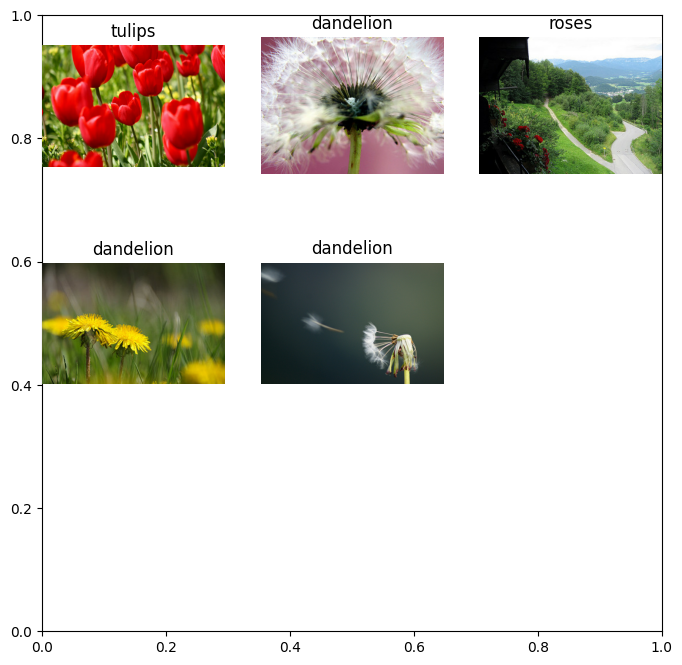

In [8]:
class_names = dataset_info.features['label'].names

plt.figure(figsize=(8,8))

for image, label in train_ds.take(9):
    plt.subplot(3,3,len(plt.gca().images)+1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")

plt.show()


In [9]:
IMG_SIZE = (160,160)

train_ds = train_ds.map(
    lambda x,y:(tf.image.resize(x,IMG_SIZE)/255.0,y)
)

validation_ds = validation_ds.map(
    lambda x,y:(tf.image.resize(x,IMG_SIZE)/255.0,y)
)

train_ds = train_ds.batch(32)

validation_ds = validation_ds.batch(32)


In [10]:
base_model = MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights='imagenet'
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
base_model.trainable = False

In [12]:
model = Sequential([

base_model,

layers.GlobalAveragePooling2D(),

layers.Dense(128,activation='relu'),

layers.Dropout(0.3),

layers.Dense(5,activation='softmax')

])


In [13]:
model.compile(

optimizer='adam',

loss='sparse_categorical_crossentropy',

metrics=['accuracy']

)


In [14]:
history = model.fit(

train_ds,

validation_data=validation_ds,

epochs=5

)


Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 94s 902ms/step - accuracy: 0.7619 - loss: 0.6450 - val_accuracy: 0.8665 - val_loss: 0.3710
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.8832 - loss: 0.3213 - val_accuracy: 0.8787 - val_loss: 0.3258
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 115s 817ms/step - accuracy: 0.9240 - loss: 0.2170 - val_accuracy: 0.8869 - val_loss: 0.3109
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 77s 842ms/step - accuracy: 0.9448 - loss: 0.1667 - val_accuracy: 0.8801 - val_loss: 0.3306
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 84s 854ms/step - accuracy: 0.9598 - loss: 0.1271 - val_accuracy: 0.8815 - val_loss: 0.3272


In [15]:
loss,accuracy=model.evaluate(validation_ds)

print("Accuracy =",accuracy)


23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 661ms/step - accuracy: 0.8815 - loss: 0.3272
Accuracy = 0.8814713954925537


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted: roses
Actual: roses


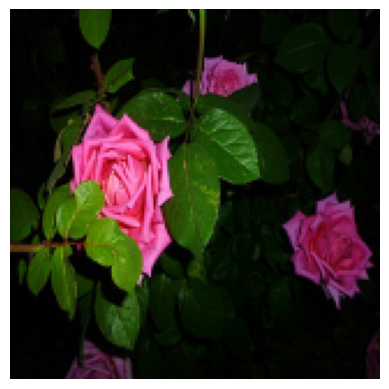

In [16]:
for image,label in validation_ds.take(1):

    prediction=model.predict(image)

    predicted=np.argmax(prediction[0])

    print("Predicted:",class_names[predicted])

    print("Actual:",class_names[label[0]])

    plt.imshow(image[0])

    plt.axis("off")

    plt.show()


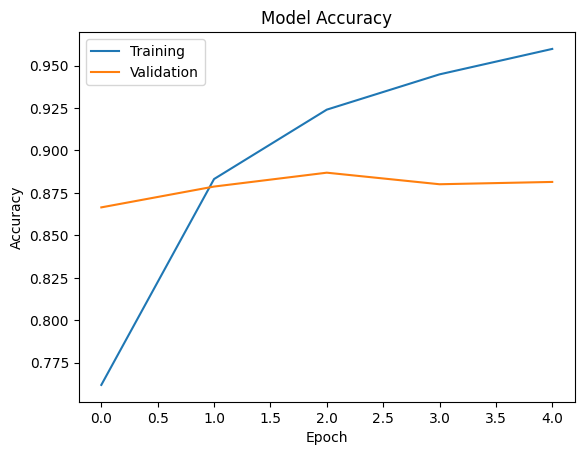

In [17]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Training","Validation"])

plt.show()

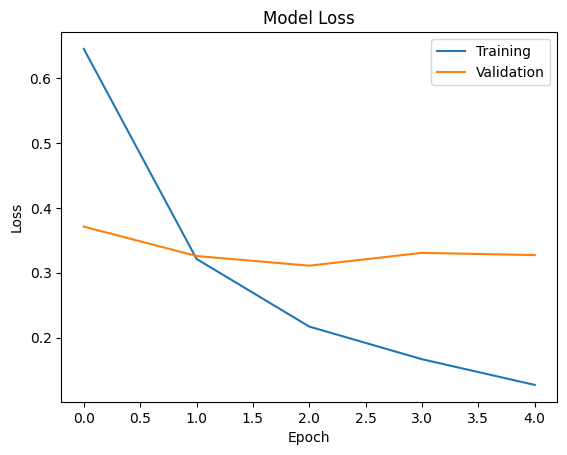

In [18]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Training","Validation"])

plt.show()
